In [1]:
!pip install ucimlrepo
!pip install tensorflow
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 755.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 86.8 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00


### 1,α)

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
adult = fetch_ucirepo(id=2)


X = adult.data.features
y = adult.data.targets

X['target'] = y #join before the filtering

print(adult.variables)
X.describe()




              name     role         type      demographic  \
0              age  Feature      Integer              Age   
1        workclass  Feature  Categorical           Income   
2           fnlwgt  Feature      Integer             None   
3        education  Feature  Categorical  Education Level   
4    education-num  Feature      Integer  Education Level   
5   marital-status  Feature  Categorical            Other   
6       occupation  Feature  Categorical            Other   
7     relationship  Feature  Categorical            Other   
8             race  Feature  Categorical             Race   
9              sex  Feature       Binary              Sex   
10    capital-gain  Feature      Integer             None   
11    capital-loss  Feature      Integer             None   
12  hours-per-week  Feature      Integer             None   
13  native-country  Feature  Categorical            Other   
14          income   Target       Binary           Income   

                       

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [3]:
missing_counts = X.isnull().sum()
print("Missing values in each column:")
print(missing_counts)

placeholder = '?'
missing_placeholders = (X == placeholder).sum()
print("\nColumns with ? values:")
print(missing_placeholders)

Missing values in each column:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
target              0
dtype: int64

Columns with ? values:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
target               0
dtype: int64


In [4]:
X = X.replace('?', np.nan)

# Count missing (NaN) values in each column
missing_counts = X.isnull().sum()

# Calculate percentage of missing (NaN) values
missing_percentage = (missing_counts / X.shape[0]) * 100

# Display count and percentage of NaN values
print("Missing values in each column (count and percentage):")
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
print(missing_info)

Missing values in each column (count and percentage):
                Missing Count  Missing Percentage
age                         0            0.000000
workclass                2799            5.730724
fnlwgt                      0            0.000000
education                   0            0.000000
education-num               0            0.000000
marital-status              0            0.000000
occupation               2809            5.751198
relationship                0            0.000000
race                        0            0.000000
sex                         0            0.000000
capital-gain                0            0.000000
capital-loss                0            0.000000
hours-per-week              0            0.000000
native-country            857            1.754637
target                      0            0.000000


In [5]:
# Replace missing values in 'occupation' with the mode
if 'occupation' in X.columns:
    if X['occupation'].isnull().any():
        occupation_mode = X['occupation'].mode()[0]  # Calculate mode
        X['occupation'] = X['occupation'].fillna(occupation_mode)  # Replace NaN with mode

# Replace missing values in 'workclass' with 'unknown' (new category)
if 'workclass' in X.columns:
    if X['workclass'].isnull().any():
        X['workclass'] = X['workclass'].fillna('unknown')  # Replace NaN with 'unknown'

# Drop rows where 'native-country' is NaN
if 'native-country' in X.columns:
    X = X.dropna(subset=['native-country'])  # Drop rows with NaN in 'native-country'


# Check for missing values after these operations
missing_counts_after = X.isnull().sum()
print("\nMissing values in each column after specific handling:")
print(missing_counts_after)



Missing values in each column after specific handling:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
target            0
dtype: int64


In [6]:
# Remove invalid rows based on hours-per-week , age constraints and capital gain / loss
X = X[(X['hours-per-week'] <= 120) & (X['hours-per-week'] >= 0)]  # Valid hours-per-week
X = X[(X['age'] <= 100) & (X['age'] >= 10)]  # Valid age range
X = X[X['capital-gain'] >= 0]
X = X[X['capital-loss'] >= 0]
X = X[X['capital-gain'] != 99999]
X = X[X['capital-loss'] != 99999]

X = X.drop('fnlwgt', axis=1) #not useful here
X = X.drop('education', axis=1) #not useful here because we have education-num
# Reset index after filtering
X.reset_index(drop=True, inplace=True)

#Turn the sex into int
X['sex'] = X['sex'].replace({'Male': 0, 'Female': 1})

# Replace the target categories with 0 and 1
X['target'] = X['target'].replace({'<=50K': 0, '<=50K.': 0, '>50K': 1, '>50K.': 1})
X['target'] = X['target'].astype(int)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47751 entries, 0 to 47750
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47751 non-null  int64 
 1   workclass       47751 non-null  object
 2   education-num   47751 non-null  int64 
 3   marital-status  47751 non-null  object
 4   occupation      47751 non-null  object
 5   relationship    47751 non-null  object
 6   race            47751 non-null  object
 7   sex             47751 non-null  int64 
 8   capital-gain    47751 non-null  int64 
 9   capital-loss    47751 non-null  int64 
 10  hours-per-week  47751 non-null  int64 
 11  native-country  47751 non-null  object
 12  target          47751 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 4.7+ MB


/tmp/ipykernel_15233/3651594870.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['sex'] = X['sex'].replace({'Male': 0, 'Female': 1})
/tmp/ipykernel_15233/3651594870.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['target'] = X['target'].replace({'<=50K': 0, '<=50K.': 0, '>50K': 1, '>50K.': 1})


In [7]:
X.describe()
X_cleaned_copy = X.copy()


### 1, β)

In [8]:
X['age'] = (X['age'] - X['age'].min()) / (X['age'].max() - X['age'].min()) #Age normalisation

# Verify the normalization
print("Age column after normalization:")
print(X['age'].describe())

Age column after normalization:
count    47751.000000
mean         0.295920
std          0.188099
min          0.000000
25%          0.150685
50%          0.273973
75%          0.424658
max          1.000000
Name: age, dtype: float64


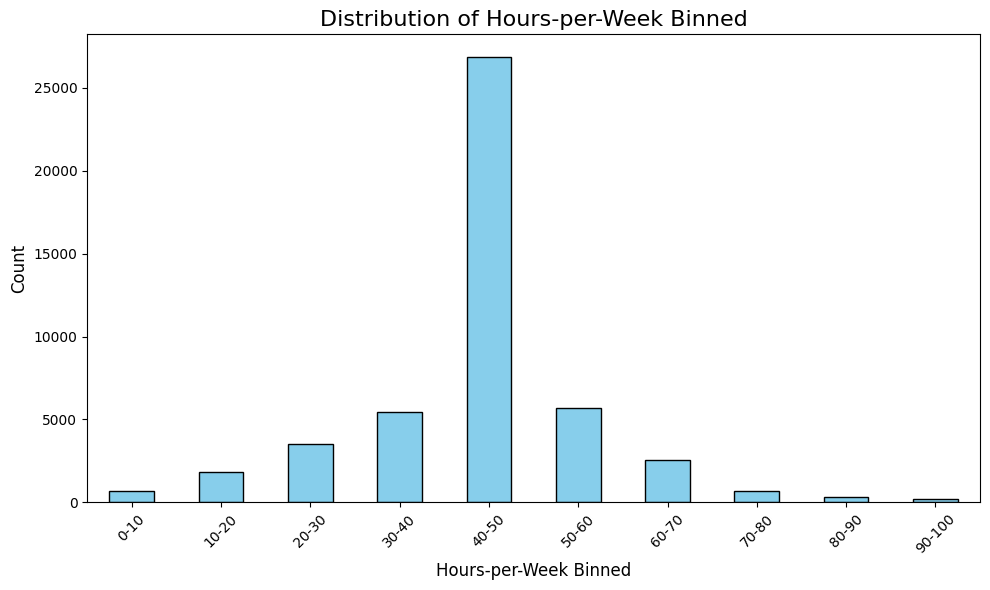

/tmp/ipykernel_15233/3372205969.py:47: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['hours-per-week-binned'] = X['hours-per-week-binned'].replace(hours_mapping)
/tmp/ipykernel_15233/3372205969.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X['hours-per-week-binned'] = X['hours-per-week-binned'].replace(hours_mapping)


In [9]:
import matplotlib.pyplot as plt

# Assuming X is your DataFrame and 'hours-per-week' is already in it

# Bin the 'hours-per-week' column in steps of 10 from 0 to 100
bins = list(range(0, 101, 10))  # Bins from 0 to 100 in steps of 10
labels = [f'{i}-{i+10}' for i in bins[:-1]]  # Labels for the bins (e.g., '0-10', '10-20', ..., '90-100')

X['hours-per-week-binned'] = pd.cut(X['hours-per-week'], bins=bins, labels=labels, right=False)

# Drop the original 'hours-per-week' column
X = X.drop('hours-per-week', axis=1)

# Count the frequency of each bin
bin_counts = X['hours-per-week-binned'].value_counts().sort_index()

# Plot the distribution of the binned 'hours-per-week'
plt.figure(figsize=(10, 6))
bin_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Hours-per-Week Binned', fontsize=16)
plt.xlabel('Hours-per-Week Binned', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

hours_mapping = {
    '0-10':  0,
    '10-20': 1,
    '20-30': 2,
    '30-40': 3,
    '40-50': 4,
    '50-60': 5,
    '60-70': 6,
    '70-80': 7,
    '80-90': 8,
    '90-100':9
}

# Replace the binned values with ordinal numbers
X['hours-per-week-binned'] = X['hours-per-week-binned'].replace(hours_mapping)
X['hours-per-week-binned'] = X['hours-per-week-binned'].astype(int)



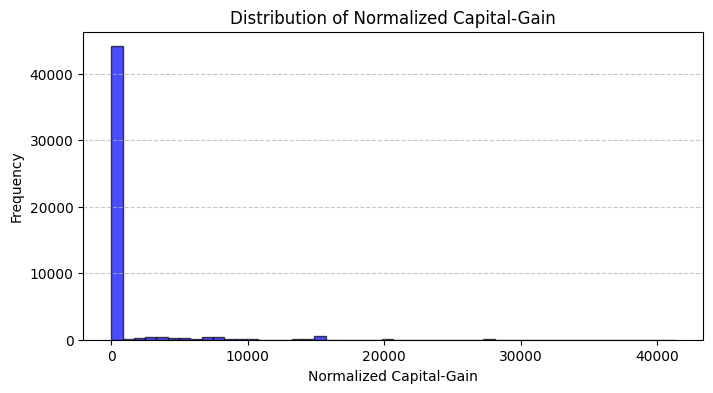

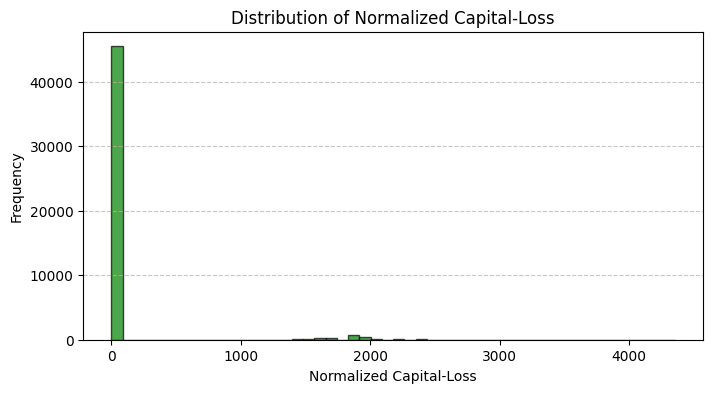

In [10]:
# Plot histogram for capital-gain
plt.figure(figsize=(8, 4))
plt.hist(X['capital-gain'], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Normalized Capital-Gain')
plt.xlabel('Normalized Capital-Gain')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Similarly for capital-loss
plt.figure(figsize=(8, 4))
plt.hist(X['capital-loss'], bins=50, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribution of Normalized Capital-Loss')
plt.xlabel('Normalized Capital-Loss')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Capital-gain column after log-plus-one normalization:
count    47751.000000
mean         0.674687
std          2.329152
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.628884
Name: capital-gain, dtype: float64

Capital-loss column after log-plus-one normalization:
count    47751.000000
mean         0.352212
std          1.588865
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          8.379539
Name: capital-loss, dtype: float64


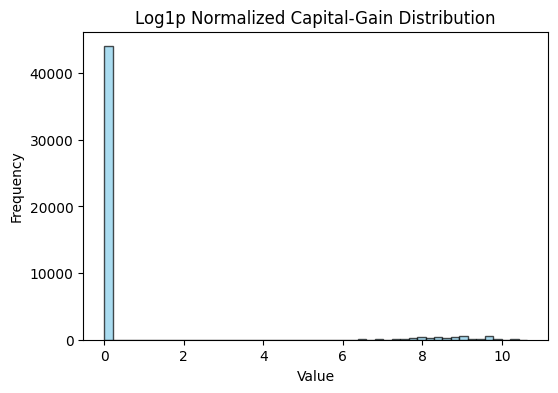

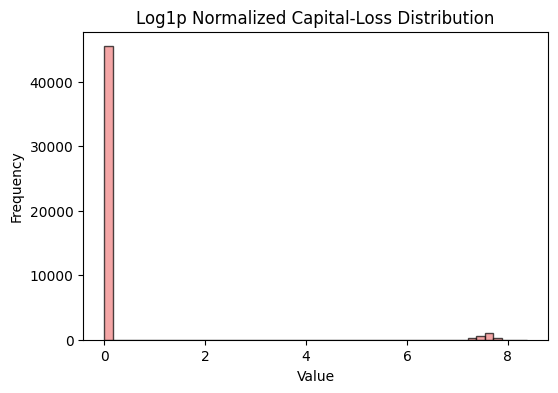

In [11]:
# Apply log-plus-one transformation to 'capital-gain' and 'capital-loss'
X[['capital-gain', 'capital-loss']] = np.log1p(X[['capital-gain', 'capital-loss']])

# Verify the normalization
print("Capital-gain column after log-plus-one normalization:")
print(X['capital-gain'].describe())

print("\nCapital-loss column after log-plus-one normalization:")
print(X['capital-loss'].describe())

plt.figure(figsize=(6, 4))
plt.hist(X['capital-gain'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Log1p Normalized Capital-Gain Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# Create a figure and axis for the second plot (capital-loss)
plt.figure(figsize=(6, 4))
plt.hist(X['capital-loss'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Log1p Normalized Capital-Loss Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


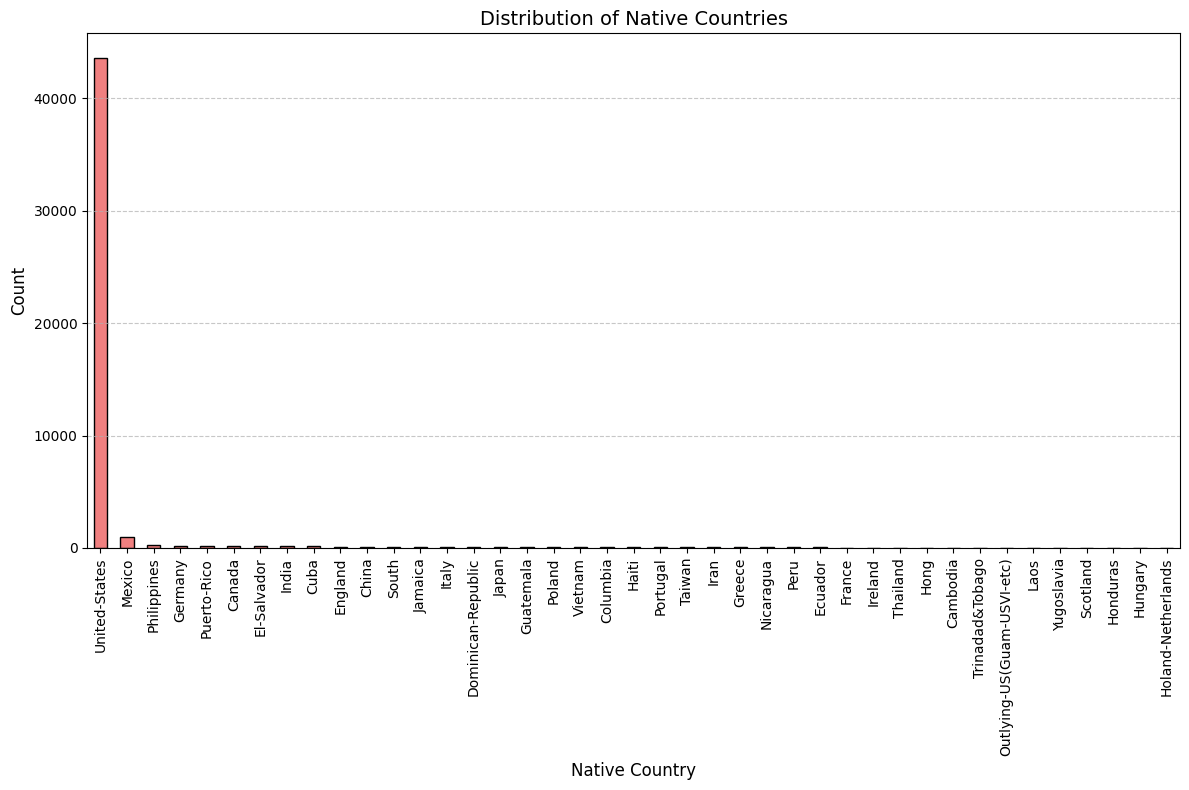

In [12]:
# Get the counts of each unique native-country
country_counts = X['native-country'].value_counts()

# Plot the distribution as a bar chart
plt.figure(figsize=(12, 8))
country_counts.plot(kind='bar', color='lightcoral', edgecolor='black')

# Add labels and title
plt.title("Distribution of Native Countries", fontsize=14)
plt.xlabel("Native Country", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [13]:
X.info()
# Convert all object columns to category
for column in X.select_dtypes(include='object').columns:
    X[column] = X[column].astype('category')
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47751 entries, 0 to 47750
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    47751 non-null  float64
 1   workclass              47751 non-null  object 
 2   education-num          47751 non-null  int64  
 3   marital-status         47751 non-null  object 
 4   occupation             47751 non-null  object 
 5   relationship           47751 non-null  object 
 6   race                   47751 non-null  object 
 7   sex                    47751 non-null  int64  
 8   capital-gain           47751 non-null  float64
 9   capital-loss           47751 non-null  float64
 10  native-country         47751 non-null  object 
 11  target                 47751 non-null  int64  
 12  hours-per-week-binned  47751 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 4.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

In [14]:
y = X['target']  # Extract the target column
X = X.drop(columns=['target'])  # Drop the target column

print(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 47751 entries, 0 to 47750
Series name: target
Non-Null Count  Dtype
--------------  -----
47751 non-null  int64
dtypes: int64(1)
memory usage: 373.2 KB
None


## 1,γ)

### 1. Principal Component Analysis (PCA)

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Make a copy of the original dataset
X_pca_copy = X.copy()
y_pca_copy = y.copy()

# Identify categorical columns
categorical_columns = X_pca_copy.select_dtypes(exclude=[np.number]).columns

# Apply Label Encoding to categorical columns
label_encoder = LabelEncoder()

# Label encode each categorical column
for column in categorical_columns:
    X_pca_copy[column] = label_encoder.fit_transform(X_pca_copy[column])

# Standardize the features before applying PCA (only numeric columns)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_copy.select_dtypes(include=[np.number]))  # Apply to numeric columns

# Apply PCA to reduce dimensions while retaining 95% of the variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Check how many components were selected
print(f"Number of components selected: {X_pca.shape[1]}")

# Print explained variance ratio to verify how much variance is retained
print(f"Explained variance ratio: {sum(pca.explained_variance_ratio_)}")



Number of components selected: 11
Explained variance ratio: 0.9677903132186587


### 2. Random Sampling

In [16]:
# Assuming X and y are the feature matrix and target variable
# Randomly sample 50% of the data, using the same indices for both X and y
sample_size = int(0.5 * len(X))  # 50% of the data size
random_indices = np.random.choice(X.index, size=sample_size, replace=False)

# Apply the same random indices to X and y
X_sampled = X.loc[random_indices]  # Select the rows from X based on the sampled indices
y_sampled = y.loc[random_indices]  # Select the corresponding rows from y

# Now both X_sampled and y_sampled are aligned with the same sampled indices
original_size = len(X)  # Number of rows in the original data
sampled_size = len(X_sampled)  # Number of rows in the sampled data

print(f"Original data size: {original_size}")
print(f"Sampled data size: {sampled_size}")
print(f"Sampled data is {sampled_size / original_size * 100:.2f}% of the original data")

Original data size: 47751
Sampled data size: 23875
Sampled data is 50.00% of the original data


### 3. Stratified Sampling

Original data size: 47751
Stratified sampled data size: 23875
Stratified sampled data is 50.00% of the original data


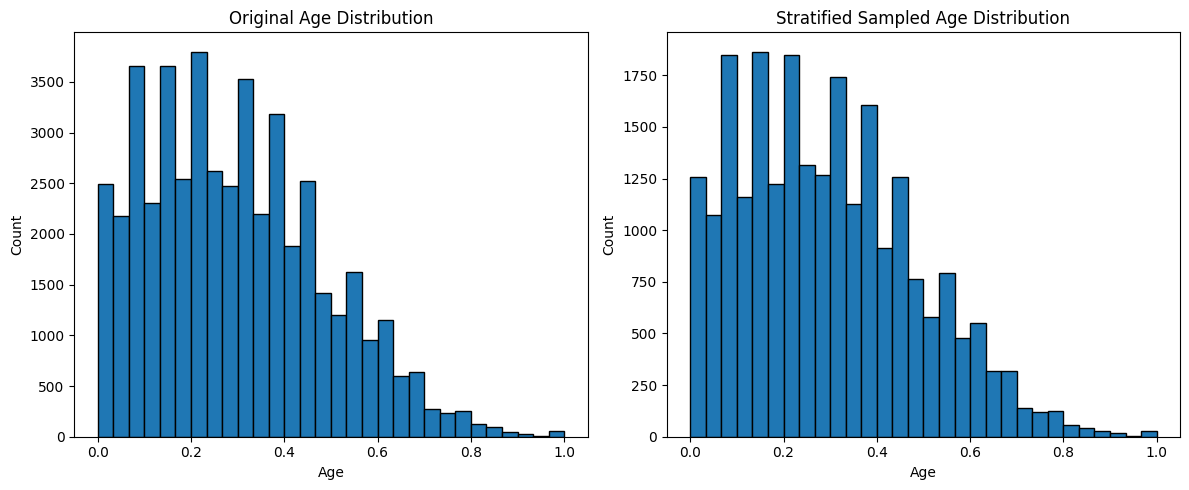

In [17]:
from sklearn.model_selection import train_test_split

X_ss_copy = X.copy()
y_ss_copy = y.copy()

# Step 1: Perform Stratified Sampling
X_sampled, X_remaining, y_sampled, y_remaining = train_test_split(
    X_ss_copy, y_ss_copy, test_size=0.5, random_state=42, stratify=y_ss_copy  # Use y_filtered for stratification
)

# Step 2: Confirm Sample Size
original_size = len(X)  # Number of rows in the original data
sampled_size = len(X_sampled)  # Number of rows in the stratified sampled data

print(f"Original data size: {original_size}")
print(f"Stratified sampled data size: {sampled_size}")
print(f"Stratified sampled data is {sampled_size / original_size * 100:.2f}% of the original data")

# Step 3: Visualize a Feature Distribution (Optional)
# For example, visualizing the 'age' feature
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original data distribution for 'age' feature
axes[0].hist(X['age'], bins=30, edgecolor='black')
axes[0].set_title('Original Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Stratified sampled data distribution for 'age' feature
axes[1].hist(X_sampled['age'], bins=30, edgecolor='black')
axes[1].set_title('Stratified Sampled Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()




In [18]:
X.info()
print(X.head())
print(X.columns.tolist())
for col in X.select_dtypes(include=['object']).columns:
    print(f"{col}: {X[col].nunique()} unique categories")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47751 entries, 0 to 47750
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    47751 non-null  float64 
 1   workclass              47751 non-null  category
 2   education-num          47751 non-null  int64   
 3   marital-status         47751 non-null  category
 4   occupation             47751 non-null  category
 5   relationship           47751 non-null  category
 6   race                   47751 non-null  category
 7   sex                    47751 non-null  int64   
 8   capital-gain           47751 non-null  float64 
 9   capital-loss           47751 non-null  float64 
 10  native-country         47751 non-null  category
 11  hours-per-week-binned  47751 non-null  int64   
dtypes: category(6), float64(3), int64(3)
memory usage: 2.5 MB
        age         workclass  education-num      marital-status  \
0  0.301370       

### 2,α)

In [19]:
X_copy = X.copy()
y_copy = y.copy()

X_copy['target'] = y_copy  # Join target column

### 1. Pearson & Spearman Correlation

Pearson Correlation with Target:
age                      0.227273
education-num            0.327429
sex                     -0.213238
capital-gain             0.264476
capital-loss             0.140900
hours-per-week-binned    0.217778
Name: target, dtype: float64

Spearman Correlation with Target:
age                      0.266341
education-num            0.322391
sex                     -0.213238
capital-gain             0.255460
capital-loss             0.140846
hours-per-week-binned    0.248788
Name: target, dtype: float64


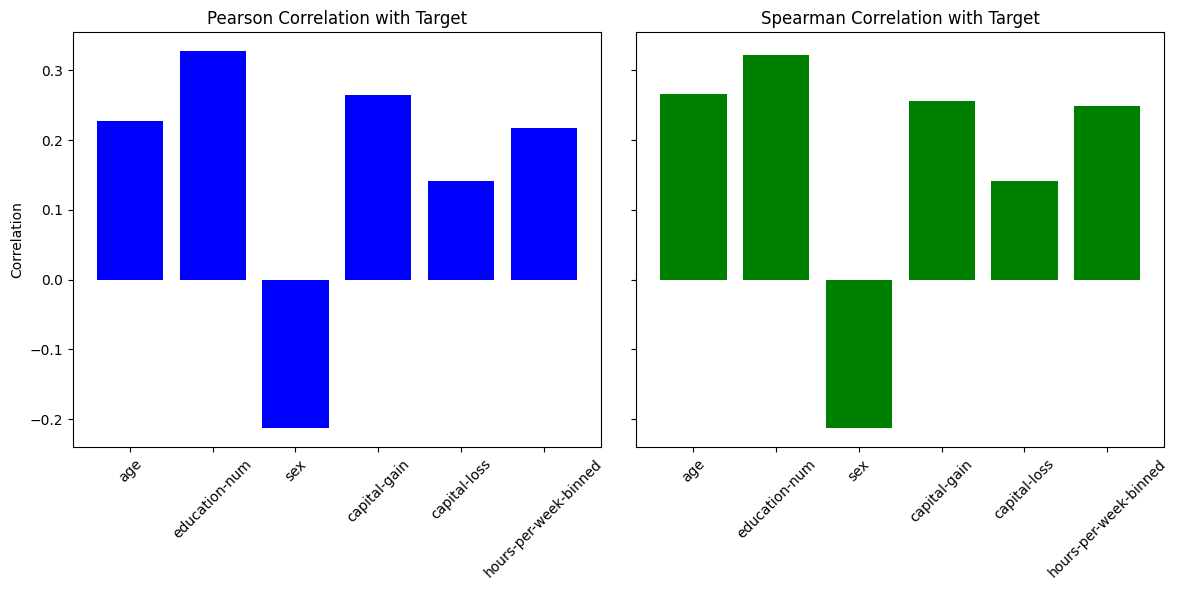

In [20]:
# Select only numerical columns (including target)
numerical_columns = X_copy.select_dtypes(include=[np.number]).columns

# Calculate the Pearson correlation of each numerical feature with the target
corr_with_target_pearson = X_copy[numerical_columns].corr(method='pearson')['target'].drop('target')

# Calculate the Spearman correlation of each numerical feature with the target
corr_with_target_spearman = X_copy[numerical_columns].corr(method='spearman')['target'].drop('target')

# Display the correlation values for Pearson and Spearman
print("Pearson Correlation with Target:")
print(corr_with_target_pearson)

print("\nSpearman Correlation with Target:")
print(corr_with_target_spearman)

# Plot the correlations side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Pearson plot
axes[0].bar(corr_with_target_pearson.index, corr_with_target_pearson.values, color='blue')
axes[0].set_title('Pearson Correlation with Target')
axes[0].set_ylabel('Correlation')
axes[0].set_xticks(range(len(corr_with_target_pearson.index)))
axes[0].set_xticklabels(corr_with_target_pearson.index, rotation=45)

# Spearman plot
axes[1].bar(corr_with_target_spearman.index, corr_with_target_spearman.values, color='green')
axes[1].set_title('Spearman Correlation with Target')
axes[1].set_xticks(range(len(corr_with_target_spearman.index)))
axes[1].set_xticklabels(corr_with_target_spearman.index, rotation=45)

plt.tight_layout()
plt.show()

Το αρνητικό πρόσημο δείχνει ότι υπάρχει σχέση μεταξύ του income και του sex(για μικρό sex , εδώ 0 δηλαδή άνδρας το income είναι πιό πιθανά >= 50k)

### 2. SelectKBest

In [21]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# Step 1: Make a copy of the original data for processing
X_copy_selected = X_copy.copy()

# Step 2: One-Hot Encoding for categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

# One-hot encode categorical columns
X_copy_selected = pd.get_dummies(X_copy_selected, columns=categorical_columns, drop_first=True)

# Step 3: Exclude the target column (if it's included in the features)
# Ensure target column is not included in the feature set for SelectKBest
X_copy_selected = X_copy_selected.drop(columns=['target'], errors='ignore')

# Step 4: Apply SelectKBest with mutual_info_classif
selector = SelectKBest(mutual_info_classif, k=5)  # Select top 5 features
X_selected = selector.fit_transform(X_copy_selected, y_copy)

# Step 5: Get the selected features
selected_features = selector.get_support(indices=True)
selected_columns = X_copy_selected.columns[selected_features]

# Display the selected features
print("Selected Features:", selected_columns)

Selected Features: Index(['age', 'education-num', 'capital-gain',
       'marital-status_Married-civ-spouse', 'marital-status_Never-married'],
      dtype='object')


### 3. Feature importance scores (Random Forest Classifier)

Training set size: 38200 samples
Test set size: 9551 samples
Top 5 Features: Index(['age', 'education-num', 'capital-gain',
       'marital-status_Married-civ-spouse', 'hours-per-week-binned'],
      dtype='object')


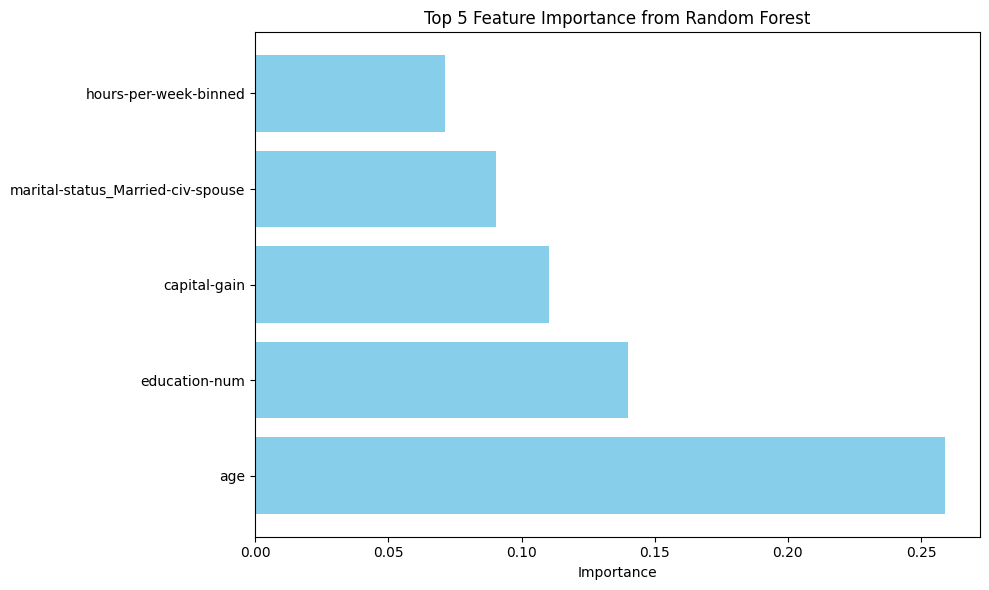

Accuracy on all features: 0.8493
Training time: 2.8484 seconds
Accuracy with top 5 features: 0.8455
Training time with top 5 features: 1.6023 seconds

Comparison:
Accuracy on all features: 0.8493
Accuracy on top 5 features: 0.8455
Training time on all features: 2.8484 seconds
Training time on top 5 features: 1.6023 seconds


In [22]:
from sklearn.ensemble import RandomForestClassifier
import time
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Step 1: Make a copy of the original data for processing
X_copy_selected = X_copy.copy()
X_copy_selected = X_copy_selected.drop(columns=['target'], errors='ignore')

# Step 2: One-Hot Encoding for categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

# One-hot encode categorical columns (drop_first=True to avoid multicollinearity)
X_copy_selected = pd.get_dummies(X_copy_selected, columns=categorical_columns, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_copy_selected, y_copy, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Initialize the Random Forest Classifier
rf_all = RandomForestClassifier(random_state=42)

# Start timing the training
start_time = time.time()

# Train the model on all features
rf_all.fit(X_train, y_train)

# Calculate training time
training_time_all = time.time() - start_time

# Make predictions and calculate accuracy
y_pred_all = rf_all.predict(X_test)
accuracy_all = accuracy_score(y_test, y_pred_all)

# Get the feature importance scores
feature_importances_all = rf_all.feature_importances_

# Get the top 5 important features
top_5_features_indices = feature_importances_all.argsort()[-5:][::-1]
top_5_features = X_train.columns[top_5_features_indices]

print(f"Top 5 Features: {top_5_features}")

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Use the encoded columns
    'Importance': feature_importances_all
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select the top 5 important features
top_5 = importance_df.head(5)

# Plot the top 5 features
plt.figure(figsize=(10, 6))
plt.barh(top_5['Feature'], top_5['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 5 Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

print(f"Accuracy on all features: {accuracy_all:.4f}")
print(f"Training time: {training_time_all:.4f} seconds")

# Create a new DataFrame with only the top 5 features
X_train_top_5 = X_train[top_5_features]
X_test_top_5 = X_test[top_5_features]

# Initialize and train the model with only the top 5 features
rf_top_5 = RandomForestClassifier(random_state=42)

# Start timing the training
start_time = time.time()

# Train the model
rf_top_5.fit(X_train_top_5, y_train)

# Calculate training time
training_time_top_5 = time.time() - start_time

# Make predictions and calculate accuracy
y_pred_top_5 = rf_top_5.predict(X_test_top_5)
accuracy_top_5 = accuracy_score(y_test, y_pred_top_5)

# Display the comparison
print(f"Accuracy with top 5 features: {accuracy_top_5:.4f}")
print(f"Training time with top 5 features: {training_time_top_5:.4f} seconds")

# Print comparison
print("\nComparison:")
print(f"Accuracy on all features: {accuracy_all:.4f}")
print(f"Accuracy on top 5 features: {accuracy_top_5:.4f}")
print(f"Training time on all features: {training_time_all:.4f} seconds")
print(f"Training time on top 5 features: {training_time_top_5:.4f} seconds")



### 2,β)

In [23]:
X_cleaned_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47751 entries, 0 to 47750
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47751 non-null  int64 
 1   workclass       47751 non-null  object
 2   education-num   47751 non-null  int64 
 3   marital-status  47751 non-null  object
 4   occupation      47751 non-null  object
 5   relationship    47751 non-null  object
 6   race            47751 non-null  object
 7   sex             47751 non-null  int64 
 8   capital-gain    47751 non-null  int64 
 9   capital-loss    47751 non-null  int64 
 10  hours-per-week  47751 non-null  int64 
 11  native-country  47751 non-null  object
 12  target          47751 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 4.7+ MB


### 1. IQR (hours per week)

Number of outliers in 'hours-per-week': 13169
       hours-per-week
1                  13
6                  16
10                 80
12                 30
19                 60
...               ...
47730               8
47732              55
47735              32
47736              32
47750              60

[13169 rows x 1 columns]


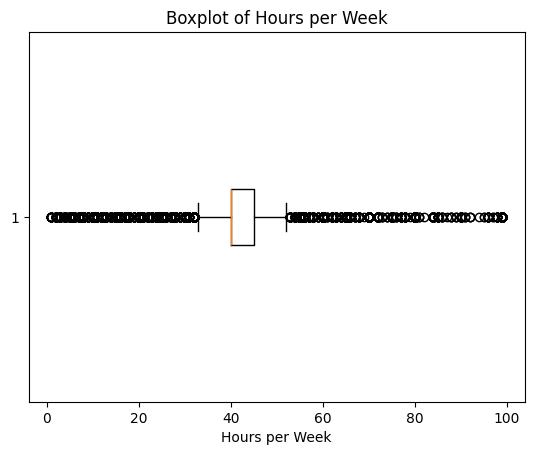

In [24]:
# Step 1: Calculate Q1, Q3, and IQR
q1 = X_cleaned_copy['hours-per-week'].quantile(0.25)
q3 = X_cleaned_copy['hours-per-week'].quantile(0.75)
iqr = q3 - q1

# Step 2: Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Step 3: Identify the outliers
outliers = X_cleaned_copy[(X_cleaned_copy['hours-per-week'] < lower_bound) |
                          (X_cleaned_copy['hours-per-week'] > upper_bound)]

print(f"Number of outliers in 'hours-per-week': {len(outliers)}")
print(outliers[['hours-per-week']])

# Step 4: Visualize using a horizontal boxplot
plt.boxplot(X_cleaned_copy['hours-per-week'], vert=False)
plt.title('Boxplot of Hours per Week')
plt.xlabel('Hours per Week')
plt.show()


Το hours per week έχει πολλά outliers , λόγω μικρής διασποράς. Στη συγκεκριμένη περίπτωση δεν δηλώνουν κάτι ύποπτο.

### 2. Z-Score για outliers σε capital gain / loss , Boxplots

Number of outliers in 'capital-gain': 991
       capital-gain  z_score_capital_gain
8             14084              5.323652
80            14344              5.426168
96            15024              5.694287
101           34095             13.213843
192           14084              5.323652
...             ...                   ...
47419         15020              5.692710
47441         14344              5.426168
47656         15024              5.694287
47695         27828             10.742811
47732         15024              5.694287

[991 rows x 2 columns]
Number of outliers in 'capital-loss': 2173
       capital-loss  z_score_capital_loss
22             2042              4.841682
31             1408              3.270899
49             1902              4.494821
91             1902              4.494821
107            1887              4.457657
...             ...                   ...
47693          1602              3.751548
47704          2057              4.878845
47712    

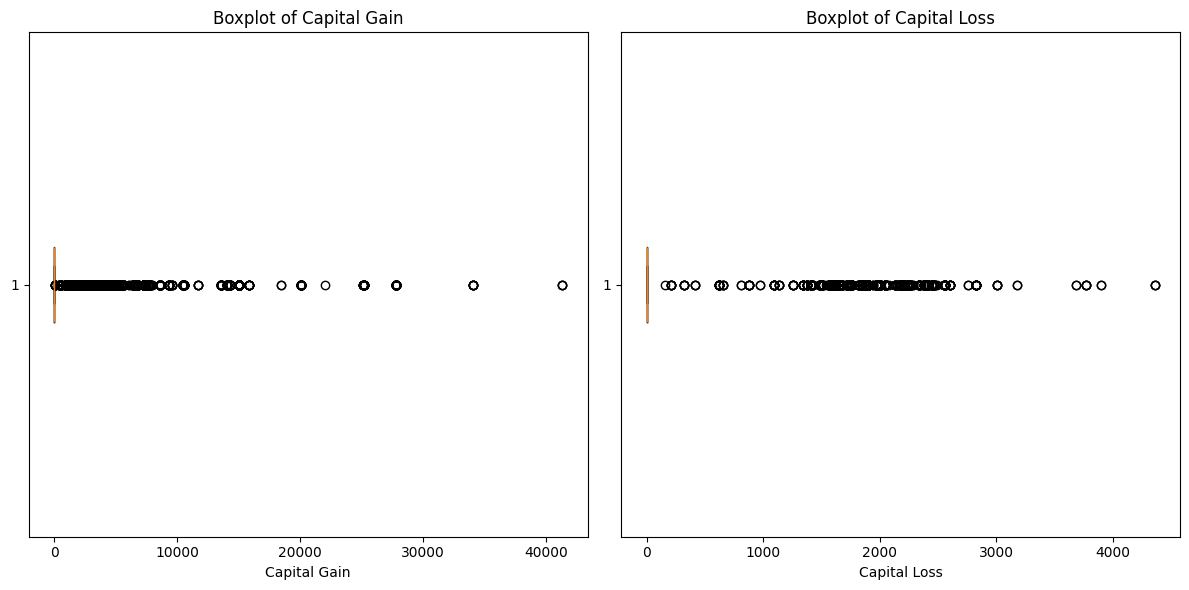

In [25]:
# Calculate Z-scores for 'capital-gain'
capital_gain_mean = X_cleaned_copy['capital-gain'].mean()
capital_gain_std = X_cleaned_copy['capital-gain'].std()
X_cleaned_copy['z_score_capital_gain'] = (X_cleaned_copy['capital-gain'] - capital_gain_mean) / capital_gain_std
outliers_gain = X_cleaned_copy[np.abs(X_cleaned_copy['z_score_capital_gain']) > 3]

# Print outliers for 'capital-gain'
print(f"Number of outliers in 'capital-gain': {len(outliers_gain)}")
print(outliers_gain[['capital-gain', 'z_score_capital_gain']])

# Calculate Z-scores for 'capital-loss'
capital_loss_mean = X_cleaned_copy['capital-loss'].mean()
capital_loss_std = X_cleaned_copy['capital-loss'].std()
X_cleaned_copy['z_score_capital_loss'] = (X_cleaned_copy['capital-loss'] - capital_loss_mean) / capital_loss_std
outliers_loss = X_cleaned_copy[np.abs(X_cleaned_copy['z_score_capital_loss']) > 3]

# Print outliers for 'capital-loss'
print(f"Number of outliers in 'capital-loss': {len(outliers_loss)}")
print(outliers_loss[['capital-loss', 'z_score_capital_loss']])

# Visualize using horizontal boxplots
plt.figure(figsize=(12, 6))

# Boxplot for 'capital-gain'
plt.subplot(1, 2, 1)
plt.boxplot(X_cleaned_copy['capital-gain'], vert=False)
plt.title('Boxplot of Capital Gain')
plt.xlabel('Capital Gain')

# Boxplot for 'capital-loss'
plt.subplot(1, 2, 2)
plt.boxplot(X_cleaned_copy['capital-loss'], vert=False)
plt.title('Boxplot of Capital Loss')
plt.xlabel('Capital Loss')

plt.tight_layout()
plt.show()


Βρίσκουμε πολλά outliers καθώς και στις δύο περιπτώσεις η συντριπτική πλειοψηφεία έχει δηλώσει μηδενικό capital gain / loss

### 3. Hours-per-week / age scatter plot

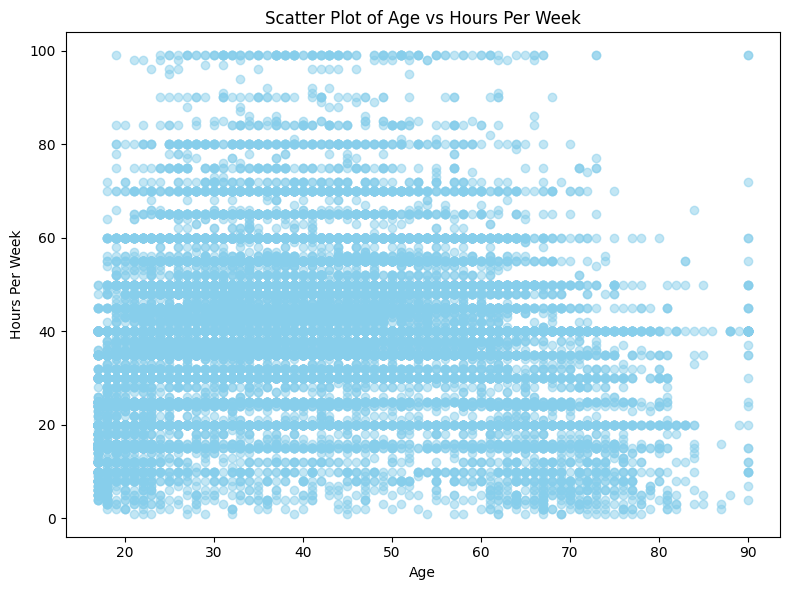

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(X_cleaned_copy['age'], X_cleaned_copy['hours-per-week'], alpha=0.5, color='skyblue')
plt.title('Scatter Plot of Age vs Hours Per Week')
plt.xlabel('Age')
plt.ylabel('Hours Per Week')
plt.tight_layout()
plt.show()


Προφανές outlier (ηλικία 90 , ώρες εργασίας 99) , μάλλον μη έγκυρες πληροφορίες γενικότερα , άρα το διαγράφουμε από το DB. (Έχει ήδη διαγραφτεί στο 1ο μέρος της άσκησης το συγκεκριμένο row). Παρατηρούμε επίσης οριζόντιες γραμμές στα πολλαπλάσια του 5 στις ώρες ανά εβδομάδα. Αυτό είναι λογικό αφού συνήθως η εργασία είναι 5 ημέρες την εβδομάδα και οι ώρες / ημέρα φυσικοί αριθμοί

### 3) Clustering

In [27]:
X_copy_cluster = X.copy()
y_copy_cluster = y.copy()

X_copy_cluster['target'] = y_copy  # Join target column
X_copy_cluster.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47751 entries, 0 to 47750
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    47751 non-null  float64 
 1   workclass              47751 non-null  category
 2   education-num          47751 non-null  int64   
 3   marital-status         47751 non-null  category
 4   occupation             47751 non-null  category
 5   relationship           47751 non-null  category
 6   race                   47751 non-null  category
 7   sex                    47751 non-null  int64   
 8   capital-gain           47751 non-null  float64 
 9   capital-loss           47751 non-null  float64 
 10  native-country         47751 non-null  category
 11  hours-per-week-binned  47751 non-null  int64   
 12  target                 47751 non-null  int64   
dtypes: category(6), float64(3), int64(4)
memory usage: 2.8 MB


### 1. No categoricals

In [ ]:
from sklearn.cluster import MiniBatchKMeans, DBSCAN, BisectingKMeans , Birch
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Step 1: Select only the preprocessed numerical columns
numerical_features = ['age', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week-binned']
X_numerical = X_copy_cluster[numerical_features]

# Step 2: Clustering with K-Means
kmeans = MiniBatchKMeans(n_clusters=10, random_state=67)
kmeans_labels = kmeans.fit_predict(X_numerical)

# Step 3: Clustering with Bisecting K-Means
bisecting_kmeans = BisectingKMeans(n_clusters=10, random_state=67)
bisecting_labels = bisecting_kmeans.fit_predict(X_numerical)

# Step 4: Clustering with DBSCAN
dbscan = DBSCAN(eps=3, min_samples=15)  # Adjust hyperparameters as needed
dbscan_labels = dbscan.fit_predict(X_numerical)

birch = Birch(n_clusters=10)
birch_labels = birch.fit_predict(X_numerical)

# Print the evaluation results
def compute_cluster_target_distribution(labels, target):
    """Compute the percentage of each target class inside each cluster."""
    cluster_info = pd.DataFrame({'Cluster': labels, 'Target': target})
    cluster_distribution = cluster_info.groupby('Cluster')['Target'].value_counts(normalize=True).unstack() * 100
    cluster_distribution = cluster_distribution.fillna(0)  # Fill NaN for missing categories
    return cluster_distribution

# Compute target distribution in each cluster
kmeans_distribution = compute_cluster_target_distribution(kmeans_labels, X_copy_cluster['target'])
bisecting_distribution = compute_cluster_target_distribution(bisecting_labels, X_copy_cluster['target'])
dbscan_distribution = compute_cluster_target_distribution(dbscan_labels, X_copy_cluster['target'])
birch_distribution = compute_cluster_target_distribution(birch_labels, X_copy_cluster['target'])

# Print cluster distributions
print("\nK-Means Clustering Target Distribution:\n", kmeans_distribution)
print("\nBisecting K-Means Clustering Target Distribution:\n", bisecting_distribution)
print("\nDBSCAN Clustering Target Distribution:\n", dbscan_distribution)
print("\nBIRCH Clustering Target Distribution:\n", birch_distribution)


# Step 8: Visualize the Clustering Results
plt.figure(figsize=(28, 6))

# K-Means scatter plot
plt.subplot(1, 4, 1)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=kmeans_labels, cmap='viridis', s=10)
plt.title('K-Means Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

# Bisecting K-Means scatter plot
plt.subplot(1, 4, 2)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=bisecting_labels, cmap='viridis', s=10)
plt.title('Bisecting K-Means Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

# DBSCAN scatter plot
plt.subplot(1, 4, 3)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=dbscan_labels, cmap='viridis', s=10)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

# BIRCH scatter plot
plt.subplot(1, 4, 4)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=birch_labels, cmap='viridis', s=10)
plt.title('BIRCH Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

plt.tight_layout()
plt.show()



### 2. One Hot

In [ ]:
from sklearn.cluster import MiniBatchKMeans, DBSCAN, BisectingKMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import Birch  # Import BIRCH

# Step 1: One-hot encode all categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
X_with_dummies = pd.get_dummies(X_copy_cluster, columns=categorical_columns, drop_first=True)

# Step 2: Select numerical and one-hot encoded columns
numerical_features = ['age', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week-binned']
X_numerical = X_with_dummies[numerical_features]

# Step 3: Clustering with MiniBatchKMeans
kmeans = MiniBatchKMeans(n_clusters=10, random_state=67)
kmeans_labels = kmeans.fit_predict(X_numerical)

# Step 4: Clustering with Bisecting K-Means
bisecting_kmeans = BisectingKMeans(n_clusters=10, random_state=67)
bisecting_labels = bisecting_kmeans.fit_predict(X_numerical)

# Step 5: Clustering with DBSCAN
dbscan = DBSCAN(eps=3, min_samples=15)  # Adjust hyperparameters as needed
dbscan_labels = dbscan.fit_predict(X_numerical)

# Step 6: Clustering with BIRCH
birch = Birch(n_clusters=10)
birch_labels = birch.fit_predict(X_numerical)

# Print the evaluation results
def compute_cluster_target_distribution(labels, target):
    """Compute the percentage of each target class inside each cluster."""
    cluster_info = pd.DataFrame({'Cluster': labels, 'Target': target})
    cluster_distribution = cluster_info.groupby('Cluster')['Target'].value_counts(normalize=True).unstack() * 100
    cluster_distribution = cluster_distribution.fillna(0)  # Fill NaN for missing categories
    return cluster_distribution

# Compute target distribution in each cluster
kmeans_distribution = compute_cluster_target_distribution(kmeans_labels, X_copy_cluster['target'])
bisecting_distribution = compute_cluster_target_distribution(bisecting_labels, X_copy_cluster['target'])
dbscan_distribution = compute_cluster_target_distribution(dbscan_labels, X_copy_cluster['target'])
birch_distribution = compute_cluster_target_distribution(birch_labels, X_copy_cluster['target'])

# Print cluster distributions
print("\nK-Means Clustering Target Distribution:\n", kmeans_distribution)
print("\nBisecting K-Means Clustering Target Distribution:\n", bisecting_distribution)
print("\nDBSCAN Clustering Target Distribution:\n", dbscan_distribution)
print("\nBIRCH Clustering Target Distribution:\n", birch_distribution)


# Step 8: Visualize the Clustering Results
plt.figure(figsize=(28, 6))

# K-Means scatter plot
plt.subplot(1, 4, 1)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=kmeans_labels, cmap='viridis', s=10)
plt.title('K-Means Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

# Bisecting K-Means scatter plot
plt.subplot(1, 4, 2)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=bisecting_labels, cmap='viridis', s=10)
plt.title('Bisecting K-Means Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

# DBSCAN scatter plot
plt.subplot(1, 4, 3)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=dbscan_labels, cmap='viridis', s=10)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

# BIRCH scatter plot
plt.subplot(1, 4, 4)
plt.scatter(X_numerical['age'], X_numerical['capital-gain'], c=birch_labels, cmap='viridis', s=10)
plt.title('BIRCH Clustering Results')
plt.xlabel('Age')
plt.ylabel('Capital Gain')

plt.tight_layout()
plt.show()


### 4) Classification

### 1. KNN

In [ ]:
X_copy_class = X.copy()
y_copy_class = y.copy()

X_copy_class['target'] = y_copy  # Join target column
X_copy_class.info()

In [ ]:
# Step 1: Make a copy of the dataset
X_copy_class_encoded = X_copy_class.copy()

# Step 2: One-hot encode the categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
X_copy_class_encoded = pd.get_dummies(X_copy_class_encoded, columns=categorical_columns, drop_first=True)




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Split the dataset into training and testing sets (80% training, 20% testing)

# For the first dataset (numerical features only)
X_numerical = X_copy_class[['age', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week-binned']]
y = X_copy_class['target']

X_train_num, X_test_num, y_train, y_test = train_test_split(X_numerical, y, test_size=0.2, random_state=42)

# For the second dataset (one-hot encoded categorical features)
X_encoded = X_copy_class_encoded.drop('target', axis=1)  # Drop target column from encoded data
X_train_encoded, X_test_encoded = train_test_split(X_encoded, test_size=0.2, random_state=42)

# Step 2: Create and train KNN classifier for both datasets

# KNN for numerical features
knn_num = KNeighborsClassifier(n_neighbors=5)
knn_num.fit(X_train_num, y_train)

# KNN for one-hot encoded features
knn_encoded = KNeighborsClassifier(n_neighbors=5)
knn_encoded.fit(X_train_encoded, y_train)

# Step 3: Predict and evaluate the models

# Predictions for numerical features
y_pred_num = knn_num.predict(X_test_num)
accuracy_num = accuracy_score(y_test, y_pred_num)

# Predictions for one-hot encoded features
y_pred_encoded = knn_encoded.predict(X_test_encoded)
accuracy_encoded = accuracy_score(y_test, y_pred_encoded)

# Print evaluation results
print("KNN Model using Numerical Features:")
print(f"Accuracy: {accuracy_num:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_num))

print("\nKNN Model using One-Hot Encoded Features:")
print(f"Accuracy: {accuracy_encoded:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_encoded))
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Calculate accuracy for both models
accuracy_num = accuracy_score(y_test, y_pred_num)
accuracy_encoded = accuracy_score(y_test, y_pred_encoded)

# Calculate precision for both models
precision_num = precision_score(y_test, y_pred_num, average='weighted')  # 'weighted' for multi-class
precision_encoded = precision_score(y_test, y_pred_encoded, average='weighted')

# Calculate recall for both models
recall_num = recall_score(y_test, y_pred_num, average='weighted')  # 'weighted' for multi-class
recall_encoded = recall_score(y_test, y_pred_encoded, average='weighted')

# Display the results
print("KNN Model using Numerical Features:")
print(f"Accuracy: {accuracy_num:.4f}")
print(f"Precision: {precision_num:.4f}")
print(f"Recall: {recall_num:.4f}")

print("\nKNN Model using One-Hot Encoded Features:")
print(f"Accuracy: {accuracy_encoded:.4f}")
print(f"Precision: {precision_encoded:.4f}")
print(f"Recall: {recall_encoded:.4f}")


### 2. Naive Bayes

In [ ]:
X_copy_class1 = X.copy()
y_copy_class1 = y.copy()

X_copy_class1['target'] = y_copy  # Join target column
X_copy_class1.info()

In [ ]:
# Step 1: Make a copy of the dataset
X_copy_class1_encoded = X_copy_class1.copy()

# Step 2: One-hot encode the categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
X_copy_class1_encoded = pd.get_dummies(X_copy_class1_encoded, columns=categorical_columns, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Step 1: Split the dataset into training and testing sets (80% training, 20% testing)

# For the first dataset (numerical features only)
X_numerical = X_copy_class1[['age', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week-binned']]
y = X_copy_class1['target']

X_train_num, X_test_num, y_train, y_test = train_test_split(X_numerical, y, test_size=0.2, random_state=42)

# For the second dataset (one-hot encoded categorical features)
X_encoded = X_copy_class1_encoded.drop('target', axis=1)  # Drop target column from encoded data
X_train_encoded, X_test_encoded = train_test_split(X_encoded, test_size=0.2, random_state=42)

# Step 2: Create and train Naive Bayes classifiers for both datasets

# Naive Bayes for numerical features (GaussianNB for continuous data)
nb_num = GaussianNB()
nb_num.fit(X_train_num, y_train)

# Naive Bayes for one-hot encoded features
nb_encoded = GaussianNB()
nb_encoded.fit(X_train_encoded, y_train)

# Step 3: Predict and evaluate the models

# Predictions for numerical features
y_pred_num = nb_num.predict(X_test_num)
accuracy_num = accuracy_score(y_test, y_pred_num)
precision_num = precision_score(y_test, y_pred_num, average='weighted')  # 'weighted' for multi-class
recall_num = recall_score(y_test, y_pred_num, average='weighted')  # 'weighted' for multi-class

# Predictions for one-hot encoded features
y_pred_encoded = nb_encoded.predict(X_test_encoded)
accuracy_encoded = accuracy_score(y_test, y_pred_encoded)
precision_encoded = precision_score(y_test, y_pred_encoded, average='weighted')
recall_encoded = recall_score(y_test, y_pred_encoded, average='weighted')

# Step 4: Print evaluation results

print("Naive Bayes Model using Numerical Features:")
print(f"Accuracy: {accuracy_num:.4f}")
print(f"Precision: {precision_num:.4f}")
print(f"Recall: {recall_num:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_num))

print("\nNaive Bayes Model using One-Hot Encoded Features:")
print(f"Accuracy: {accuracy_encoded:.4f}")
print(f"Precision: {precision_encoded:.4f}")
print(f"Recall: {recall_encoded:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_encoded))


### 3. Support Vector Machine

In [ ]:
X_copy_class2 = X.copy()
y_copy_class2 = y.copy()

X_copy_class2['target'] = y_copy  # Join target column
X_copy_class2.info()


In [ ]:
# Step 1: Make a copy of the dataset
X_copy_class2_encoded = X_copy_class1.copy()

# Step 2: One-hot encode the categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
X_copy_class2_encoded = pd.get_dummies(X_copy_class2_encoded, columns=categorical_columns, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Step 1: Split the dataset into training and testing sets (80% training, 20% testing)

# For the first dataset (numerical features only)
X_numerical = X_copy_class[['age', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week-binned']]
y = X_copy_class['target']

X_train_num, X_test_num, y_train, y_test = train_test_split(X_numerical, y, test_size=0.2, random_state=42)

# For the second dataset (one-hot encoded categorical features)
X_encoded = X_copy_class2_encoded.drop('target', axis=1)  # Drop target column from encoded data
X_train_encoded, X_test_encoded = train_test_split(X_encoded, test_size=0.2, random_state=42)

# Step 2: Create and train SVM classifier for both datasets

# SVM for numerical features
svm_num = SVC(kernel='linear')  # Using a linear kernel
svm_num.fit(X_train_num, y_train)

# SVM for one-hot encoded features
svm_encoded = SVC(kernel='linear')  # Using a linear kernel
svm_encoded.fit(X_train_encoded, y_train)

# Step 3: Predict and evaluate the models

# Predictions for numerical features
y_pred_num = svm_num.predict(X_test_num)
accuracy_num = accuracy_score(y_test, y_pred_num)

# Predictions for one-hot encoded features
y_pred_encoded = svm_encoded.predict(X_test_encoded)
accuracy_encoded = accuracy_score(y_test, y_pred_encoded)

# Print evaluation results
print("SVM Model using Numerical Features:")
print(f"Accuracy: {accuracy_num:.4f}")
print(f"Classification Report:\n {classification_report(y_test, y_pred_num)}")

print("\nSVM Model using One-Hot Encoded Features:")
print(f"Accuracy: {accuracy_encoded:.4f}")
print(f"Classification Report:\n {classification_report(y_test, y_pred_encoded)}")

# Additional Metrics: Precision and Recall for both models
precision_num = precision_score(y_test, y_pred_num, average='weighted')
precision_encoded = precision_score(y_test, y_pred_encoded, average='weighted')

recall_num = recall_score(y_test, y_pred_num, average='weighted')
recall_encoded = recall_score(y_test, y_pred_encoded, average='weighted')

print("\nSVM Model using Numerical Features:")
print(f"Precision: {precision_num:.4f}")
print(f"Recall: {recall_num:.4f}")

print("\nSVM Model using One-Hot Encoded Features:")
print(f"Precision: {precision_encoded:.4f}")
print(f"Recall: {recall_encoded:.4f}")


### 5) NN

In [ ]:
X_copy_nn = X.copy()
y_copy_nn = y.copy()

X_copy_nn['target'] = y_copy  # Join target column
X_copy_nn.info()

In [ ]:
# Step 1: Make a copy of the dataset
X_copy_nn_encoded = X_copy_nn.copy()

# Step 2: One-hot encode the categorical columns
categorical_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
X_copy_nn_encoded = pd.get_dummies(X_copy_nn_encoded, columns=categorical_columns, drop_first=True)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix
import seaborn as sns

# Load your datasets
X_numerical = X_copy_nn[['age', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week-binned']]
y = X_copy_nn['target']

X_encoded = X_copy_nn_encoded.drop('target', axis=1)  # One-hot encoded version

# Split data (60% train, 10% validation, 30% test)
X_train_num, X_temp_num, y_train, y_temp = train_test_split(X_numerical, y, test_size=0.4, random_state=42)
X_val_num, X_test_num, y_val, y_test = train_test_split(X_temp_num, y_temp, test_size=0.75, random_state=42)  # 10% val, 30% test

X_train_enc, X_temp_enc, y_train_enc, y_temp_enc = train_test_split(X_encoded, y, test_size=0.4, random_state=42)
X_val_enc, X_test_enc, y_val_enc, y_test_enc = train_test_split(X_temp_enc, y_temp_enc, test_size=0.75, random_state=42)  # 10% val, 30% test

# Function to build MLP model
def build_mlp(input_shape):
    model = keras.Sequential([
        keras.layers.Dense(128, activation='gelu', input_shape=(input_shape,)),
        keras.layers.Dense(256, activation='gelu'),
        keras.layers.Dense(512, activation='gelu'),
        keras.layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train MLP for Numerical Features
mlp_num = build_mlp(X_train_num.shape[1])
history_num = mlp_num.fit(X_train_num, y_train, validation_data=(X_val_num, y_val), epochs=30, batch_size=64, verbose=1)

# Train MLP for One-Hot Encoded Features
mlp_enc = build_mlp(X_train_enc.shape[1])
history_enc = mlp_enc.fit(X_train_enc, y_train_enc, validation_data=(X_val_enc, y_val_enc), epochs=15, batch_size=64, verbose=1)

# Predictions
y_pred_num = (mlp_num.predict(X_test_num) > 0.5).astype("int32")
y_pred_enc = (mlp_enc.predict(X_test_enc) > 0.5).astype("int32")

# Calculate Recall, Precision, and Accuracy
recall_num = recall_score(y_test, y_pred_num)
precision_num = precision_score(y_test, y_pred_num)
accuracy_num = accuracy_score(y_test, y_pred_num)

recall_enc = recall_score(y_test_enc, y_pred_enc)
precision_enc = precision_score(y_test_enc, y_pred_enc)
accuracy_enc = accuracy_score(y_test_enc, y_pred_enc)

# Print Recall, Precision, and Accuracy
print(f"MLP with Numerical Features - Recall: {recall_num:.4f}, Precision: {precision_num:.4f}, Accuracy: {accuracy_num:.4f}")
print(f"MLP with One-Hot Encoded Features - Recall: {recall_enc:.4f}, Precision: {precision_enc:.4f}, Accuracy: {accuracy_enc:.4f}")

# Confusion Matrices
conf_matrix_num = confusion_matrix(y_test, y_pred_num)
conf_matrix_enc = confusion_matrix(y_test_enc, y_pred_enc)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_num, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix - Numerical Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_enc, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix - One-Hot Encoded Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()

# Loss and Accuracy Plots
# Plotting Loss and Accuracy for Numerical Features
plt.figure(figsize=(12, 6))

# Loss for Numerical Features
plt.subplot(1, 2, 1)
plt.plot(history_num.history['loss'], label='Training Loss')
plt.plot(history_num.history['val_loss'], label='Validation Loss')
plt.title("Loss - Numerical Features")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy for Numerical Features
plt.subplot(1, 2, 2)
plt.plot(history_num.history['accuracy'], label='Training Accuracy')
plt.plot(history_num.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy - Numerical Features")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Plotting Loss and Accuracy for One-Hot Encoded Features
plt.figure(figsize=(12, 6))

# Loss for One-Hot Encoded Features
plt.subplot(1, 2, 1)
plt.plot(history_enc.history['loss'], label='Training Loss')
plt.plot(history_enc.history['val_loss'], label='Validation Loss')
plt.title("Loss - One-Hot Encoded Features")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy for One-Hot Encoded Features
plt.subplot(1, 2, 2)
plt.plot(history_enc.history['accuracy'], label='Training Accuracy')
plt.plot(history_enc.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy - One-Hot Encoded Features")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split

# Split data (Ensuring no data leakage)
X_train_num, X_test_num, y_train, y_test = train_test_split(X_numerical, y, test_size=0.3, random_state=42)
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

# Define optimized XGBoost parameters
params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "learning_rate": 0.05,  # Slightly higher for faster learning
    "max_depth": 5,  # Reduce depth to prevent overfitting
    "min_child_weight": 10,  # Prevents noisy small splits
    "gamma": 0.3,  # Adds regularization for better precision
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "scale_pos_weight": 1.2,  # Adjusted for balance between recall & precision
    "n_estimators": 200,  # More rounds, but use early stopping
}

# Convert to XGBoost DMatrix
dtrain_num = xgb.DMatrix(X_train_num, label=y_train)
dtest_num = xgb.DMatrix(X_test_num, label=y_test)

dtrain_enc = xgb.DMatrix(X_train_enc, label=y_train_enc)
dtest_enc = xgb.DMatrix(X_test_enc, label=y_test_enc)

# Train XGBoost with early stopping
print("🚀 Training XGBoost (Numerical Features)...")
xgb_model_num = xgb.train(params, dtrain_num, num_boost_round=500, evals=[(dtest_num, "Validation")], early_stopping_rounds=20, verbose_eval=10)

print("🚀 Training XGBoost (One-Hot Encoded Features)...")
xgb_model_enc = xgb.train(params, dtrain_enc, num_boost_round=500, evals=[(dtest_enc, "Validation")], early_stopping_rounds=20, verbose_eval=10)

# Make predictions
y_pred_num = (xgb_model_num.predict(dtest_num) > 0.5).astype(int)
y_pred_enc = (xgb_model_enc.predict(dtest_enc) > 0.5).astype(int)

# Evaluate Performance
precision_num = precision_score(y_test, y_pred_num)
recall_num = recall_score(y_test, y_pred_num)
accuracy_num = accuracy_score(y_test, y_pred_num)

precision_enc = precision_score(y_test_enc, y_pred_enc)
recall_enc = recall_score(y_test_enc, y_pred_enc)
accuracy_enc = accuracy_score(y_test_enc, y_pred_enc)

# Print Final Results
print(f"🔹 **XGBoost (Numerical)** - Recall: {recall_num:.4f}, Precision: {precision_num:.4f}, Accuracy: {accuracy_num:.4f}")
print(f"🔹 **XGBoost (One-Hot Encoded)** - Recall: {recall_enc:.4f}, Precision: {precision_enc:.4f}, Accuracy: {accuracy_enc:.4f}")



# Confusion Matrices
conf_matrix_num = confusion_matrix(y_test, y_pred_num)
conf_matrix_enc = confusion_matrix(y_test_enc, y_pred_enc)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_num, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix - Numerical Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_enc, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix - One-Hot Encoded Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()



